<a href="https://colab.research.google.com/github/abhistacodes/colab-notebooks/blob/miss/UNET_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image # Added import for PIL Image

In [ ]:
# ---------------------------------------------------------------------------
# 0. Setup
# ---------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMG_SIZE = 128          # resize target (H = W = IMG_SIZE)
BATCH_SIZE = 16
NUM_CLASSES = 3          # trimap: 1=pet, 2=background, 3=boundary -> remapped to 0,1,2
NUM_EPOCHS = 15
LR = 0.1
DATA_ROOT = "./data"

Using device: cuda


The following codeblock defines a custom PyTorch Dataset class to handle both images and their corresponding segmentation masks (trimaps). Here is a breakdown of what each part does:

1. __init__ (Initialization)

    **self.base:**
    It wraps the built-in torchvision.datasets.OxfordIIITPet. By setting target_types="segmentation", it tells the dataset to return the trimap mask instead of a classification label.
    
    **self.img_transform:**
    Defines the preprocessing for the input images, including resizing them to a square, converting them to tensors (scaling pixels to [0, 1]), and normalizing them using ImageNet statistics.

2. __getitem__ (Data Retrieval)

    This method is called when you index the dataset (e.g., dataset[0]).

    **Loading:** It retrieves a raw PIL image and its corresponding trimap from the base dataset.
    **Mask Resizing:** The mask is resized to img_size. Crucially, it uses Image.Resampling.NEAREST. This is vital because masks contain discrete class IDs (1, 2, or 3). Using bilinear interpolation would create "fake" intermediate values like 1.5, which are invalid.
    
    **Normalization:** The image is processed via self.img_transform.
    
    **Label Remapping:** The original dataset uses labels 1 (Pet), 2 (Background), and 3 (Boundary).PyTorch loss functions (like CrossEntropyLoss) expect 0-indexed labels.mask - 1 converts these to 0, 1, and 2. The mask.clamp(0, NUM_CLASSES - 1) ensures all values stay within the valid range for safety.

3. **Summary:** The class ensures that every time the model requests a sample, it receives a normalized image tensor and a correctly formatted integer mask tensor, perfectly aligned and ready for training a segmentation model like U-Net.

In [ ]:
# 1. Dataset — image + trimap mask, with matching transforms
# ---------------------------------------------------------------------------
# torchvision.datasets.OxfordIIITPet natively supports target_type="segmentation",
# returning a PIL trimap (values 1,2,3). Wrap it so image & mask get the
# same resize, and the mask is converted to a LongTensor with classes {0,1,2}.

class PetSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, root, split="trainval", img_size=IMG_SIZE, download=True):

        # self.base wraps the built-in torchvision.datasets.OxfordIIITPet.
        # Explicitly setting target_types="segmentation" ensures we get the PIL mask.
        self.base = torchvision.datasets.OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=download,
        )
        self.img_size = img_size
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),  # -> [0,1], shape (3,H,W)
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, trimap = self.base[idx]  # PIL image, PIL mask (mode 'L', values 1/2/3)

        # Resize mask with NEAREST so class values are never interpolated
        trimap = trimap.resize((self.img_size, self.img_size),
                                resample=Image.Resampling.NEAREST)

        image = self.img_transform(image)

        mask = torch.from_numpy(
            __import__("numpy").array(trimap, dtype="int64")
        )

        # Original trimap labels: 1=pet(foreground), 2=background, 3=boundary
        # Remap to 0-indexed classes: 0=pet, 1=background, 2=boundary
        mask = mask - 1
        mask = mask.clamp(0, NUM_CLASSES - 1)

        return image, mask

This code implements the U-Net architecture, a popular convolutional neural network designed specifically for fast and precise image segmentation. It is structured into three building blocks:

1. **DoubleConv (The Core Block):**
Most operations in U-Net happen in pairs. This block performs two consecutive sequences of:

    Convolution: Extracts features using a 3x3 kernel.
    Batch Normalization: Stabilizes training and allows for higher learning rates.
    ReLU: Adds non-linearity to the model.
2. **Down (The Encoder):**
This represents the "contracting" path of the U-shape. It reduces the spatial dimensions (height and width) of the image while increasing the depth (number of feature channels).

    It uses MaxPool2d to halve the image size, followed by a DoubleConv to capture higher-level features.
3. **Up (The Decoder):**
This represents the "expansive" path. Its goal is to reconstruct a high-resolution mask from the compressed features.

    Transposed Convolution: Upscales the feature map to double its size.
    
    Skip Connections: This is the most critical part of U-Net. It takes high-resolution features from the corresponding Down step (the skip variable) and concatenates them with the upscaled features. This helps the model recover fine details lost during downsampling.

    Padding Adjustment: The code includes F.pad to handle cases where the input dimensions might be odd, ensuring the skip connection and upsampled tensors match perfectly in size before concatenation.

In [ ]:
# 2. U-Net architecture

class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) x 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    """Downscale then double conv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    """Upscale, concat skip connection, then double conv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Handle any off-by-one size mismatch from odd input dimensions
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2,
                      diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

The UNet class is the final assembly of the model, bringing together the encoder and decoder paths. Here is how it is structured:

1. **__ init __ (Model Assembly):**
This section defines the layers and their progression:

    base_ch: This determines the initial 'width' of the network (set to 64). As we go deeper, this number doubles (128, 256, 512, 1024), allowing the model to learn more complex patterns.

    Encoder Path (down1 to down4): These layers gradually compress the image size while increasing feature depth.

    Decoder Path (up1 to up4): These layers mirror the encoder, gradually restoring the spatial resolution.

    out_conv: A final 1x1 convolution that maps the internal feature maps back to the required number of classes (3 in this case: pet, background, boundary).
2. **forward (The Information Flow):**
This method describes how an image travels through the network:

    Encoding: The image passes through the downsampling layers. Importantly, the intermediate results (x1, x2, etc.) are saved. These are the Skip Connections.
    
    Bottleneck: x5 represents the most compressed version of the image, containing the highest-level semantic information.
    
    Decoding with Skips: As the image is upsampled, the corresponding saved feature map from the encoder is provided (e.g., self.up1(x5, x4)). This allows the decoder to combine 'where' information from the encoder with 'what' information from the bottleneck.
3. **Output:**
The model returns raw logits for each pixel. These are later converted into specific class predictions (like 'pet' or 'background') using an activation function like Softmax during training or inference.

In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=NUM_CLASSES, base_ch=64):
        super().__init__()
        self.in_conv = DoubleConv(in_channels, base_ch)
        self.down1 = Down(base_ch, base_ch * 2)
        self.down2 = Down(base_ch * 2, base_ch * 4)
        self.down3 = Down(base_ch * 4, base_ch * 8)
        self.down4 = Down(base_ch * 8, base_ch * 16)

        self.up1 = Up(base_ch * 16, base_ch * 8)
        self.up2 = Up(base_ch * 8, base_ch * 4)
        self.up3 = Up(base_ch * 4, base_ch * 2)
        self.up4 = Up(base_ch * 2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, num_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.in_conv(x)   # skip 1
        x2 = self.down1(x1)    # skip 2
        x3 = self.down2(x2)    # skip 3
        x4 = self.down3(x3)    # skip 4
        x5 = self.down4(x4)    # bottleneck

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.out_conv(x)  # (B, num_classes, H, W) — raw logits

This code handles the preparation and splitting of the Oxford-IIIT Pet dataset for training, validation, and testing. Here is the breakdown:

1. **Dataset Initialization:**
    
    It creates two instances of PetSegmentationDataset: one for the trainval split (3,680 images) and one for the test split (3,669 images).
2. **Creating the Validation Split:**
    
    Since the original dataset provides a combined training and validation set (trainval), the code manually carves out 10% of it for validation using random_split.

    A manual_seed(42) is used to ensure that the split is reproducible, meaning you get the same validation set every time you run the code.
3. **DataLoaders:**
    
    Three DataLoader objects are created to manage how data is fed into the model during training:

    train_loader: Shuffles the data so the model doesn't learn the order of images.

    val_loader & test_loader: Do not shuffle, as we only need to evaluate performance consistently.

4. **Performance Optimizations:**

    batch_size=BATCH_SIZE: Groups images together (16 in your case) to speed up processing.

    num_workers=2: Uses multi-processing to load data in the background.

    pin_memory=True: Speeds up the transfer of data from the CPU to the GPU (CUDA).

In [ ]:
# 3. Data loaders
def get_dataloaders():
    full_train = PetSegmentationDataset(DATA_ROOT, split="trainval")
    test_set = PetSegmentationDataset(DATA_ROOT, split="test")

    # carve out a validation split from trainval
    n_val = int(0.1 * len(full_train))
    n_train = len(full_train) - n_val
    train_set, val_set = random_split(full_train, [n_train, n_val],
                                       generator=torch.Generator().manual_seed(42))

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


In [ ]:
# 4. Metrics

@torch.no_grad()
def pixel_accuracy(preds, masks):
    preds = preds.argmax(dim=1)
    correct = (preds == masks).float().sum()
    total = torch.numel(masks)
    return (correct / total).item()


@torch.no_grad()
def mean_iou(preds, masks, num_classes=NUM_CLASSES, eps=1e-7):
    preds = preds.argmax(dim=1)
    ious = []
    for cls in range(num_classes):
        pred_c = (preds == cls)
        mask_c = (masks == cls)
        intersection = (pred_c & mask_c).float().sum()
        union = (pred_c | mask_c).float().sum()
        if union == 0:
            continue
        ious.append((intersection / (union + eps)).item())
    return sum(ious) / len(ious) if ious else 0.0

In [ ]:
# 5. Train / validate loops

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, running_acc = 0.0, 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)               # (B, C, H, W)
        loss = criterion(outputs, masks)      # CrossEntropyLoss expects (B,C,H,W) vs (B,H,W)
        loss.backward()                       # back propagation
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_acc += pixel_accuracy(outputs, masks) * images.size(0)

    n = len(loader.dataset)
    return running_loss / n, running_acc / n


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss, running_acc, running_iou = 0.0, 0.0, 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)

        running_loss += loss.item() * images.size(0)
        running_acc += pixel_accuracy(outputs, masks) * images.size(0)
        running_iou += mean_iou(outputs, masks) * images.size(0)

    n = len(loader.dataset)
    return running_loss / n, running_acc / n, running_iou / n

In [ ]:
# 6. Visualization

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img_tensor):
    return (img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN).clamp(0, 1)

@torch.no_grad()
def show_predictions(model, loader, num_samples=4):
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    fig, axes = plt.subplots(num_samples, 3, figsize=(9, 3 * num_samples))
    for i in range(num_samples):
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        gt = masks[i].cpu().numpy()
        pred = preds[i].cpu().numpy()

        axes[i, 0].imshow(img); axes[i, 0].set_title("Image"); axes[i, 0].axis("off")
        axes[i, 1].imshow(gt, cmap="viridis"); axes[i, 1].set_title("Ground Truth"); axes[i, 1].axis("off")
        axes[i, 2].imshow(pred, cmap="viridis"); axes[i, 2].set_title("Prediction"); axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig("predictions.png", dpi=150)
    plt.show()

100%|██████████| 792M/792M [00:29<00:00, 26.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.6MB/s]


Train: 3312 | Val: 368 | Test: 3669
Epoch  1/15 | train_loss=0.7651 train_acc=0.6937 | val_loss=0.7149 val_acc=0.7188 val_iou=0.3947
  -> Saved new best model (val_iou=0.3947)
Epoch  2/15 | train_loss=0.6794 train_acc=0.7348 | val_loss=0.6577 val_acc=0.7472 val_iou=0.4175
  -> Saved new best model (val_iou=0.4175)
Epoch  3/15 | train_loss=0.6420 train_acc=0.7525 | val_loss=0.7484 val_acc=0.7139 val_iou=0.3997
Epoch  4/15 | train_loss=0.6064 train_acc=0.7655 | val_loss=0.6241 val_acc=0.7605 val_iou=0.4362
  -> Saved new best model (val_iou=0.4362)
Epoch  5/15 | train_loss=0.5809 train_acc=0.7754 | val_loss=0.5623 val_acc=0.7826 val_iou=0.4575
  -> Saved new best model (val_iou=0.4575)
Epoch  6/15 | train_loss=0.5520 train_acc=0.7853 | val_loss=0.5773 val_acc=0.7730 val_iou=0.4429
Epoch  7/15 | train_loss=0.5268 train_acc=0.7942 | val_loss=0.5187 val_acc=0.7966 val_iou=0.4726
  -> Saved new best model (val_iou=0.4726)
Epoch  8/15 | train_loss=0.4927 train_acc=0.8068 | val_loss=0.5260 val

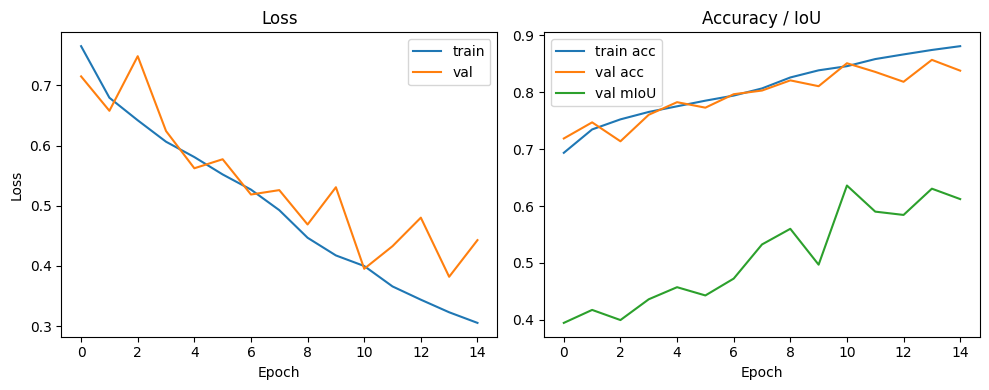

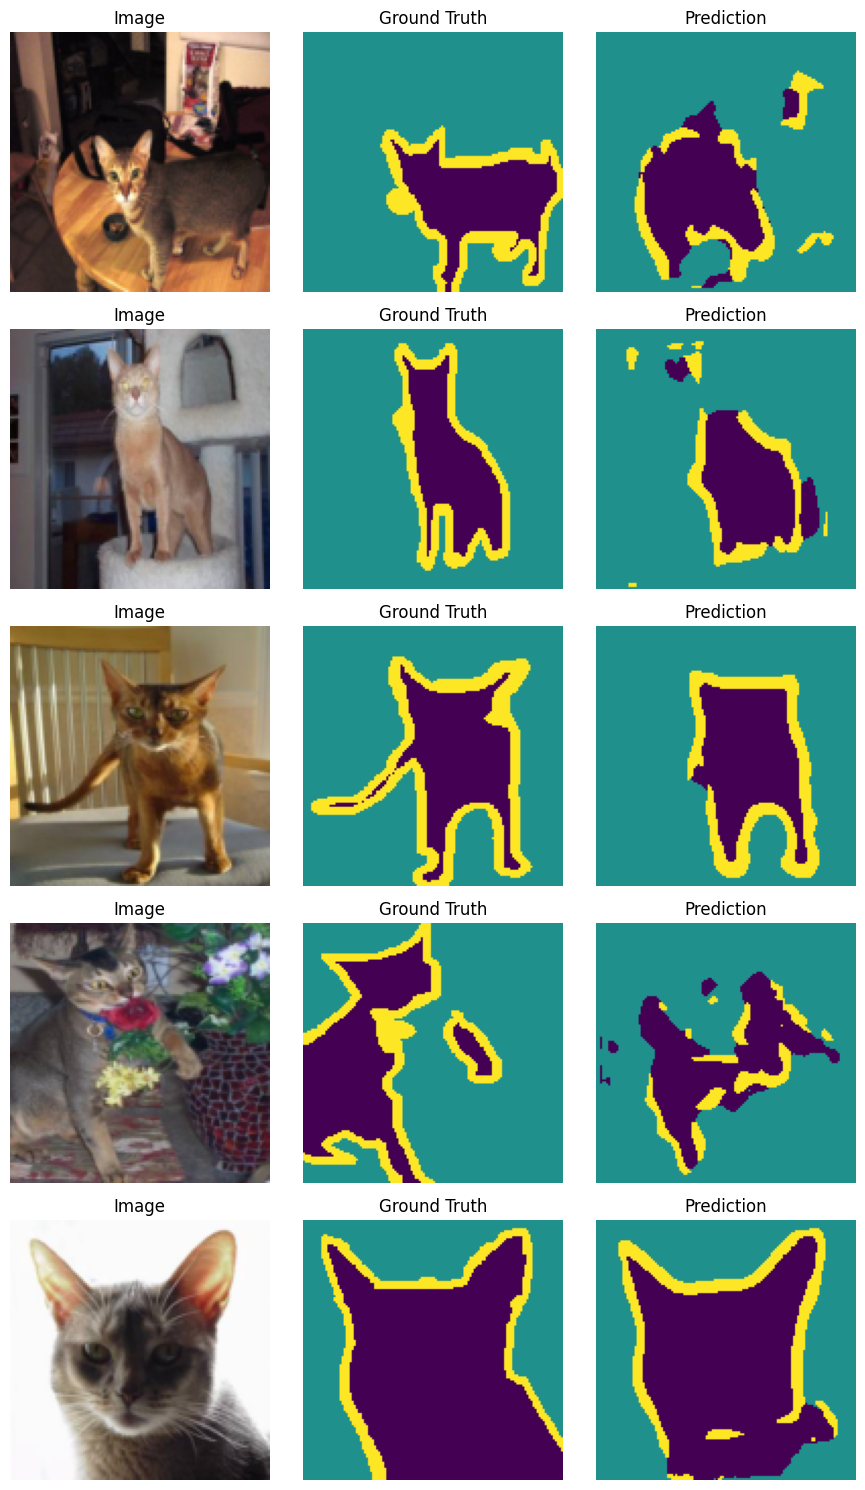

In [ ]:
# 7. Main

def main():
    train_loader, val_loader, test_loader = get_dataloaders()
    print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}")

    model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

    best_val_iou = 0.0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_iou": []}

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_iou = validate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_iou"].append(val_iou)

        print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_iou={val_iou:.4f}")

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), "best_unet_pets.pth")
            print(f"  -> Saved new best model (val_iou={val_iou:.4f})")

    # Final test evaluation
    model.load_state_dict(torch.load("best_unet_pets.pth"))
    test_loss, test_acc, test_iou = validate(model, test_loader, criterion)
    print(f"\nTest results | loss={test_loss:.4f} acc={test_acc:.4f} mIoU={test_iou:.4f}")

    # Plot loss curves
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="train acc")
    plt.plot(history["val_acc"], label="val acc")
    plt.plot(history["val_iou"], label="val mIoU")
    plt.xlabel("Epoch"); plt.legend(); plt.title("Accuracy / IoU")
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

    # Visualize a few predictions
    show_predictions(model, test_loader, num_samples=5)


if __name__ == "__main__":
    main()